# SDM378 Assignment 2: Deep Learning for Image Classification

**Course:** SDM378  
**Task:** Build and compare CNN models for image classification  
**Framework:** PyTorch  
**Dataset:** CIFAR-10 from Hugging Face (`datasets` library)

## What this notebook completes

This notebook implements all required work in the assignment:

1. A baseline CNN model for image classification.
2. Three controlled CNN comparison runs, each changing one architectural factor relative to the baseline:
   - number of convolutional layers,
   - convolution kernel size,
   - pooling design.
3. Four architecture-family runs adapted for CIFAR-10:
   - AlexNet,
   - VGG,
   - Inception,
   - ResNet.
4. A final comparison table containing:
   - model structure,
   - training time,
   - train/test accuracy,
   - test recall,
   - test F1 score.

## Reproducibility and fairness

To make comparisons academically fair:

- The baseline and three controlled CNN runs share the same training recipe.
- Each controlled run modifies only one independent variable.
- Architecture-family runs are adapted to CIFAR-10 and lightweight enough to train on personal computers.

> Important terms:  
> - **CNN (Convolutional Neural Network):** a neural network specialized for image data.  
> - **Independent variable:** one factor intentionally changed while others are held fixed.  
> - **F1 score:** harmonic mean of precision and recall, useful for balanced evaluation of classification quality.

In [16]:
# Core imports
import os
import time
import random
from dataclasses import dataclass
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from sklearn.metrics import accuracy_score, recall_score, f1_score, confusion_matrix

try:
    from datasets import load_dataset
except ImportError as e:
    raise ImportError(
        "The 'datasets' package is required. Install it with: pip install datasets"
    ) from e

sns.set_theme(style="whitegrid")

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Device selection
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cpu


## 1) Dataset loading and preprocessing

We use **CIFAR-10** (10 classes, RGB images, size `32x32`) from Hugging Face.

### Preprocessing design

- **Training transform:** random crop + horizontal flip + normalization.
- **Test transform:** normalization only.

This keeps evaluation deterministic while adding mild augmentation during training.

> Important term: **Normalization** scales pixel values so each channel has a stable mean and standard deviation, which often improves optimization stability.

In [17]:
# Load CIFAR-10 from Hugging Face
hf_dataset = load_dataset("cifar10")

class_names = hf_dataset["train"].features["label"].names
num_classes = len(class_names)
print("Classes:", class_names)
print(f"Train size: {len(hf_dataset['train'])}, Test size: {len(hf_dataset['test'])}")

# CIFAR-10 normalization constants (commonly used)
CIFAR10_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR10_STD = (0.2470, 0.2435, 0.2616)

train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
])


class HFCIFAR10Dataset(Dataset):
    """PyTorch Dataset wrapper around Hugging Face CIFAR-10 split."""

    def __init__(self, hf_split, transform=None, limit=None):
        self.hf_split = hf_split
        self.transform = transform
        self.limit = limit if limit is not None else len(hf_split)
        self.limit = min(self.limit, len(hf_split))

    def __len__(self):
        return self.limit

    def __getitem__(self, idx):
        item = self.hf_split[idx]
        image = item["img"]
        label = item["label"]
        if self.transform is not None:
            image = self.transform(image)
        return image, label


def build_dataloaders(batch_size=64, train_limit=None, test_limit=None, num_workers=0):
    train_ds = HFCIFAR10Dataset(hf_dataset["train"], transform=train_transform, limit=train_limit)
    test_ds = HFCIFAR10Dataset(hf_dataset["test"], transform=test_transform, limit=test_limit)

    train_loader = DataLoader(
        train_ds,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=torch.cuda.is_available(),
    )
    test_loader = DataLoader(
        test_ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=torch.cuda.is_available(),
    )
    return train_loader, test_loader

Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Train size: 50000, Test size: 10000


## 2) Visual inspection of samples

A quick sample visualization verifies that labels and preprocessing are loaded correctly before training starts.

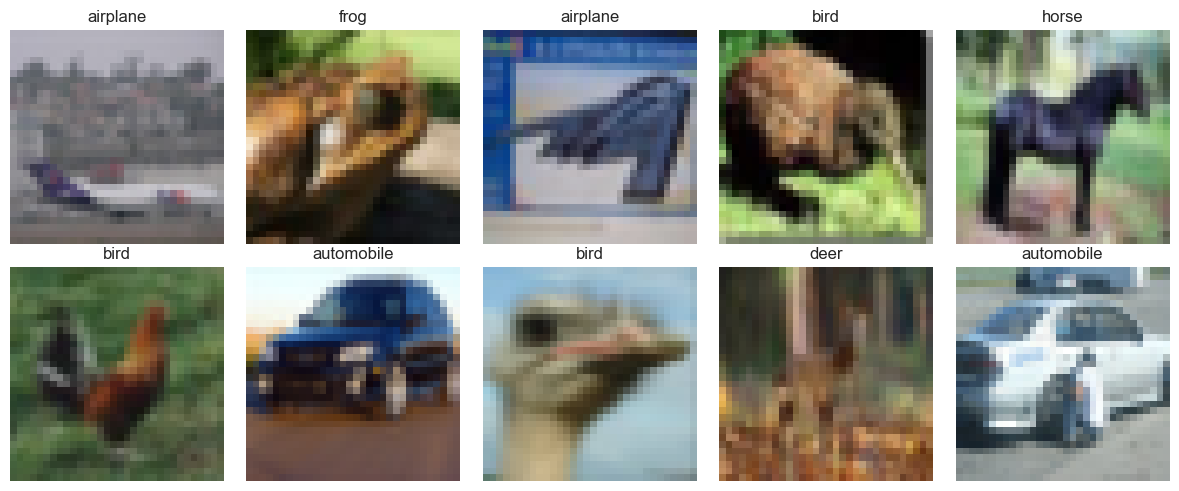

In [18]:
# Visualize a few raw samples from the Hugging Face split
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    sample = hf_dataset["train"][i]
    ax.imshow(sample["img"])
    ax.set_title(class_names[sample["label"]])
    ax.axis("off")
plt.tight_layout()
plt.show()

## 3) Reusable training and evaluation pipeline

This section defines helper functions for all experiments.

### Metrics used

- **Accuracy:** fraction of correct predictions.
- **Recall (macro):** average recall across classes, treating each class equally.
- **F1 score (macro):** harmonic mean of precision and recall, averaged equally across classes.

> Important term: **Macro average** computes the metric per class and then averages them, preventing majority classes from dominating the score.

In [19]:
@dataclass
class ExperimentResult:
    name: str
    model_family: str
    architecture_note: str
    train_time_sec: float
    train_accuracy: float
    test_accuracy: float
    test_recall_macro: float
    test_f1_macro: float


def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss = 0.0
    all_preds, all_labels = [], []

    for images, labels in loader:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * labels.size(0)
        preds = logits.argmax(dim=1)
        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_labels, all_preds)
    return avg_loss, acc


def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            logits = model(images)
            loss = criterion(logits, labels)

            total_loss += loss.item() * labels.size(0)
            preds = logits.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_labels, all_preds)
    recall = recall_score(all_labels, all_preds, average="macro", zero_division=0)
    f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)
    return avg_loss, acc, recall, f1, np.array(all_labels), np.array(all_preds)


def run_experiment(config, model_factory):
    train_loader, test_loader = build_dataloaders(
        batch_size=config["batch_size"],
        train_limit=config.get("train_limit"),
        test_limit=config.get("test_limit"),
    )

    model = model_factory().to(DEVICE)
    criterion = nn.CrossEntropyLoss()

    if config["optimizer"] == "adam":
        optimizer = optim.Adam(
            model.parameters(),
            lr=config["learning_rate"],
            weight_decay=config["weight_decay"],
        )
    elif config["optimizer"] == "sgd":
        optimizer = optim.SGD(
            model.parameters(),
            lr=config["learning_rate"],
            momentum=0.9,
            weight_decay=config["weight_decay"],
        )
    else:
        raise ValueError(f"Unsupported optimizer: {config['optimizer']}")

    history = {"train_acc": [], "test_acc": []}

    start_time = time.time()
    for epoch in range(config["epochs"]):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)
        test_loss, test_acc, test_recall, test_f1, y_true, y_pred = evaluate(model, test_loader, criterion)

        history["train_acc"].append(train_acc)
        history["test_acc"].append(test_acc)

        print(
            f"[{config['name']}] Epoch {epoch + 1}/{config['epochs']} | "
            f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f}, "
            f"test_loss={test_loss:.4f}, test_acc={test_acc:.4f}, "
            f"recall={test_recall:.4f}, f1={test_f1:.4f}"
        )

    elapsed = time.time() - start_time

    # Final train accuracy on training set for required table field
    _, final_train_acc, _, _, _, _ = evaluate(model, train_loader, criterion)
    _, final_test_acc, final_recall, final_f1, final_y_true, final_y_pred = evaluate(model, test_loader, criterion)

    result = ExperimentResult(
        name=config["name"],
        model_family=config["model_family"],
        architecture_note=config["architecture_note"],
        train_time_sec=elapsed,
        train_accuracy=final_train_acc,
        test_accuracy=final_test_acc,
        test_recall_macro=final_recall,
        test_f1_macro=final_f1,
    )

    return result, history, final_y_true, final_y_pred

## 4) Model definitions

This section implements all model classes used in the eight planned runs.

- **Baseline + controlled CNN variants:** custom compact networks.
- **Architecture-family runs:** CIFAR-10-adapted variants of AlexNet, VGG, Inception, and ResNet.

> Important term: **Model capacity** is the ability of a model to fit complex patterns. Deeper/wider models usually have higher capacity but can require more computation.

In [20]:
class BaselineCNN(nn.Module):
    """Baseline:
    Conv(3->32,3x3) -> ReLU -> MaxPool
    Conv(32->64,3x3) -> ReLU -> MaxPool
    FC(64*8*8->128) -> ReLU -> Dropout -> FC(128->10)
    """

    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.30),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


class RunA_DeeperCNN(nn.Module):
    """Controlled run A: change convolutional layer count 2 -> 3."""

    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.30),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


class RunB_Kernel5CNN(nn.Module):
    """Controlled run B: change kernel size 3x3 -> 5x5."""

    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=5, padding=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, kernel_size=5, padding=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.30),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


class RunC_AvgPoolCNN(nn.Module):
    """Controlled run C: change pooling type MaxPool -> AvgPool."""

    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.AvgPool2d(2, 2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.AvgPool2d(2, 2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.30),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


class AlexNetCIFAR(nn.Module):
    """CIFAR-10-adapted AlexNet-style network."""

    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(64, 192, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(192, 384, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(384, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(256 * 4 * 4, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


def make_vgg11_cifar(num_classes=10):
    model = models.vgg11_bn(weights=None)
    # For CIFAR-10, force pooled feature map to 1x1 to match a compact classifier.
    model.avgpool = nn.AdaptiveAvgPool2d((1, 1))
    model.classifier = nn.Sequential(
        nn.Linear(512 * 1 * 1, 512),
        nn.ReLU(True),
        nn.Dropout(0.5),
        nn.Linear(512, 256),
        nn.ReLU(True),
        nn.Dropout(0.5),
        nn.Linear(256, num_classes),
    )
    return model


def make_inception_cifar(num_classes=10):
    # torchvision Inception v3 is usually designed for larger images;
    # we disable auxiliary logits and train on resized CIFAR-10.
    model = models.inception_v3(weights=None, aux_logits=False)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model


def make_resnet18_cifar(num_classes=10):
    model = models.resnet18(weights=None)
    # CIFAR-10 adaptation: smaller kernel and no initial maxpool
    model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    model.maxpool = nn.Identity()
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

## 5) Experiment configuration

We now define all eight experiments using a common configuration format.

### Fixed training recipe (for fair controlled comparison)

For the baseline and controlled CNN runs, we keep the main recipe fixed:

- optimizer: Adam (Adaptive Moment Estimation)
- learning rate: `1e-3`
- batch size: `64`
- weight decay: `1e-4`
- same epoch count

For architecture-family runs, we keep the same recipe when possible and only adjust image size for Inception compatibility.

> Practical note: two run modes are provided:
> - `FAST_MODE=True`: smaller data subset and fewer epochs for quick testing.
> - `FAST_MODE=False`: larger subset/full set for stronger final results.

In [21]:
# Optional speed switch
FAST_MODE = True

if FAST_MODE:
    default_epochs = 3
    default_train_limit = 12000
    default_test_limit = 3000
else:
    default_epochs = 10
    default_train_limit = None
    default_test_limit = None

# In Jupyter (especially on macOS), num_workers>0 can crash DataLoader subprocesses.
DEFAULT_NUM_WORKERS = 0


def build_transforms(image_size=32):
    train_tf = transforms.Compose([
        transforms.Resize((image_size, image_size)),
        transforms.RandomCrop(image_size, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
    ])
    test_tf = transforms.Compose([
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor(),
        transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
    ])
    return train_tf, test_tf


def build_dataloaders_for_config(config):
    image_size = config.get("image_size", 32)
    num_workers = config.get("num_workers", DEFAULT_NUM_WORKERS)
    train_tf, test_tf = build_transforms(image_size=image_size)

    train_ds = HFCIFAR10Dataset(hf_dataset["train"], transform=train_tf, limit=config.get("train_limit"))
    test_ds = HFCIFAR10Dataset(hf_dataset["test"], transform=test_tf, limit=config.get("test_limit"))

    train_loader = DataLoader(
        train_ds,
        batch_size=config["batch_size"],
        shuffle=True,
        num_workers=num_workers,
        pin_memory=torch.cuda.is_available(),
    )
    test_loader = DataLoader(
        test_ds,
        batch_size=config["batch_size"],
        shuffle=False,
        num_workers=num_workers,
        pin_memory=torch.cuda.is_available(),
    )
    return train_loader, test_loader


def run_experiment_config(config, model_factory):
    train_loader, test_loader = build_dataloaders_for_config(config)

    model = model_factory().to(DEVICE)
    criterion = nn.CrossEntropyLoss()

    if config["optimizer"] == "adam":
        optimizer = optim.Adam(
            model.parameters(),
            lr=config["learning_rate"],
            weight_decay=config["weight_decay"],
        )
    elif config["optimizer"] == "sgd":
        optimizer = optim.SGD(
            model.parameters(),
            lr=config["learning_rate"],
            momentum=0.9,
            weight_decay=config["weight_decay"],
        )
    else:
        raise ValueError(f"Unsupported optimizer: {config['optimizer']}")

    history = {"train_acc": [], "test_acc": []}

    start_time = time.time()
    for epoch in range(config["epochs"]):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)
        test_loss, test_acc, test_recall, test_f1, _, _ = evaluate(model, test_loader, criterion)

        history["train_acc"].append(train_acc)
        history["test_acc"].append(test_acc)

        print(
            f"[{config['name']}] Epoch {epoch + 1}/{config['epochs']} | "
            f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f}, "
            f"test_loss={test_loss:.4f}, test_acc={test_acc:.4f}, "
            f"recall={test_recall:.4f}, f1={test_f1:.4f}"
        )

    elapsed = time.time() - start_time

    _, final_train_acc, _, _, _, _ = evaluate(model, train_loader, criterion)
    _, final_test_acc, final_recall, final_f1, final_y_true, final_y_pred = evaluate(model, test_loader, criterion)

    result = ExperimentResult(
        name=config["name"],
        model_family=config["model_family"],
        architecture_note=config["architecture_note"],
        train_time_sec=elapsed,
        train_accuracy=final_train_acc,
        test_accuracy=final_test_acc,
        test_recall_macro=final_recall,
        test_f1_macro=final_f1,
    )

    return result, history, final_y_true, final_y_pred


BASE_RECIPE = {
    "epochs": default_epochs,
    "batch_size": 64,
    "optimizer": "adam",
    "learning_rate": 1e-3,
    "weight_decay": 1e-4,
    "train_limit": default_train_limit,
    "test_limit": default_test_limit,
    "image_size": 32,
    "num_workers": DEFAULT_NUM_WORKERS,
}


experiment_specs = [
    {
        **BASE_RECIPE,
        "name": "Baseline",
        "model_family": "CustomCNN",
        "architecture_note": "2 conv, 3x3 kernels, 2 MaxPool",
        "factory": lambda: BaselineCNN(num_classes=num_classes),
    },
    {
        **BASE_RECIPE,
        "name": "Run_A_DeeperConv",
        "model_family": "CustomCNN",
        "architecture_note": "3 conv, 3x3 kernels, 2 MaxPool",
        "factory": lambda: RunA_DeeperCNN(num_classes=num_classes),
    },
    {
        **BASE_RECIPE,
        "name": "Run_B_Kernel5",
        "model_family": "CustomCNN",
        "architecture_note": "2 conv, 5x5 kernels, 2 MaxPool",
        "factory": lambda: RunB_Kernel5CNN(num_classes=num_classes),
    },
    {
        **BASE_RECIPE,
        "name": "Run_C_AvgPool",
        "model_family": "CustomCNN",
        "architecture_note": "2 conv, 3x3 kernels, 2 AvgPool",
        "factory": lambda: RunC_AvgPoolCNN(num_classes=num_classes),
    },
    {
        **BASE_RECIPE,
        "name": "AlexNet_CIFAR",
        "model_family": "AlexNet",
        "architecture_note": "CIFAR-adapted AlexNet-style network",
        "factory": lambda: AlexNetCIFAR(num_classes=num_classes),
    },
    {
        **BASE_RECIPE,
        "name": "VGG11_BN_CIFAR",
        "model_family": "VGG",
        "architecture_note": "torchvision vgg11_bn adapted classifier",
        "factory": lambda: make_vgg11_cifar(num_classes=num_classes),
    },
    {
        **BASE_RECIPE,
        "name": "InceptionV3_CIFAR",
        "model_family": "Inception",
        "architecture_note": "inception_v3 (aux disabled), resized input",
        "image_size": 75,
        "batch_size": 32,
        "factory": lambda: make_inception_cifar(num_classes=num_classes),
    },
    {
        **BASE_RECIPE,
        "name": "ResNet18_CIFAR",
        "model_family": "ResNet",
        "architecture_note": "resnet18 with CIFAR conv stem",
        "factory": lambda: make_resnet18_cifar(num_classes=num_classes),
    },
]

print(f"Total planned experiments: {len(experiment_specs)}")
for spec in experiment_specs:
    print(f"- {spec['name']}: {spec['architecture_note']}")

Total planned experiments: 8
- Baseline: 2 conv, 3x3 kernels, 2 MaxPool
- Run_A_DeeperConv: 3 conv, 3x3 kernels, 2 MaxPool
- Run_B_Kernel5: 2 conv, 5x5 kernels, 2 MaxPool
- Run_C_AvgPool: 2 conv, 3x3 kernels, 2 AvgPool
- AlexNet_CIFAR: CIFAR-adapted AlexNet-style network
- VGG11_BN_CIFAR: torchvision vgg11_bn adapted classifier
- InceptionV3_CIFAR: inception_v3 (aux disabled), resized input
- ResNet18_CIFAR: resnet18 with CIFAR conv stem


## 6) Run all experiments

This cell trains all eight planned models and stores:

- metric history,
- final predictions for analysis,
- standardized summary fields for table generation.

If runtime is too long on your machine, keep `FAST_MODE=True` first for verification, then switch to `FAST_MODE=False` for a final stronger run.

In [ ]:
all_results: List[ExperimentResult] = []
all_histories: Dict[str, Dict[str, List[float]]] = {}
all_predictions: Dict[str, Tuple[np.ndarray, np.ndarray]] = {}

for spec in experiment_specs:
    print("\n" + "=" * 80)
    print(f"Starting experiment: {spec['name']}")
    print("=" * 80)

    # The factory is stored in each spec; copy spec metadata without the callable
    run_cfg = {k: v for k, v in spec.items() if k != "factory"}

    result, history, y_true, y_pred = run_experiment_config(run_cfg, spec["factory"])
    all_results.append(result)
    all_histories[spec["name"]] = history
    all_predictions[spec["name"]] = (y_true, y_pred)

print("\nAll experiments completed.")


Starting experiment: Baseline
[Baseline] Epoch 1/3 | train_loss=1.9745, train_acc=0.2801, test_loss=1.6351, test_acc=0.4167, recall=0.4165, f1=0.4129
[Baseline] Epoch 2/3 | train_loss=1.6501, train_acc=0.3920, test_loss=1.4609, test_acc=0.4723, recall=0.4731, f1=0.4597
[Baseline] Epoch 3/3 | train_loss=1.5646, train_acc=0.4259, test_loss=1.3913, test_acc=0.5037, recall=0.5031, f1=0.4941

Starting experiment: Run_A_DeeperConv
[Run_A_DeeperConv] Epoch 1/3 | train_loss=1.9014, train_acc=0.3027, test_loss=1.5596, test_acc=0.4400, recall=0.4402, f1=0.4285


## 7) Results summary and comparison table

This section produces the assignment-required table fields:

- model description,
- training time,
- training accuracy,
- testing accuracy,
- testing recall,
- testing F1 score.

It also visualizes training curves and a confusion matrix for the best test-accuracy model.

> Important term: **Confusion matrix** summarizes prediction counts per true/predicted class and helps diagnose class-specific errors.

In [ ]:
# Build final results table
def results_to_dataframe(results: List[ExperimentResult]) -> pd.DataFrame:
    rows = []
    for r in results:
        rows.append(
            {
                "Experiment": r.name,
                "ModelFamily": r.model_family,
                "Architecture": r.architecture_note,
                "TrainingTimeSec": round(r.train_time_sec, 2),
                "TrainAccuracy": round(r.train_accuracy, 4),
                "TestAccuracy": round(r.test_accuracy, 4),
                "TestRecallMacro": round(r.test_recall_macro, 4),
                "TestF1Macro": round(r.test_f1_macro, 4),
            }
        )
    df = pd.DataFrame(rows)
    return df.sort_values(by="TestAccuracy", ascending=False).reset_index(drop=True)


results_df = results_to_dataframe(all_results)
results_df

In [ ]:
# Plot train/test accuracy curves for each model
plt.figure(figsize=(12, 6))
for exp_name, hist in all_histories.items():
    plt.plot(hist["test_acc"], label=f"{exp_name} (test)")

plt.title("Test Accuracy Curves Across Experiments")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(loc="best", fontsize=8)
plt.tight_layout()
plt.show()

# Show best model and confusion matrix
best_exp = results_df.iloc[0]["Experiment"]
y_true_best, y_pred_best = all_predictions[best_exp]

cm = confusion_matrix(y_true_best, y_pred_best)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.title(f"Confusion Matrix - Best Model: {best_exp}")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.tight_layout()
plt.show()

print(f"Best model by test accuracy: {best_exp}")
print(results_df.head(1))

## 8) Discussion and conclusion

This section summarizes key findings in assignment-report style.

### Points to discuss

1. Which controlled factor had the largest effect among:
   - convolutional layer count,
   - convolution kernel size,
   - pooling design.
2. How custom CNN variants compare with architecture-family models (AlexNet, VGG, Inception, ResNet).
3. Tradeoff between training time and classification quality.

### Suggested interpretation style

- Report **both effectiveness and cost**.
- Highlight whether gains in test F1 score justify added runtime.
- State a final recommended model for this dataset and compute setting.

In [ ]:
# Compact analysis summary for report writing
custom_df = results_df[results_df["ModelFamily"] == "CustomCNN"].copy()
arch_df = results_df[results_df["ModelFamily"] != "CustomCNN"].copy()

print("Controlled CNN runs (baseline + 3 single-factor changes):")
display(custom_df)

print("\nArchitecture-family runs (AlexNet, VGG, Inception, ResNet):")
display(arch_df)

best_row = results_df.iloc[0]
fastest_row = results_df.sort_values("TrainingTimeSec", ascending=True).iloc[0]

print("\nConclusion snippet (editable for report):")
print(
    f"Best model by test accuracy is {best_row['Experiment']} "
    f"(TestAccuracy={best_row['TestAccuracy']:.4f}, "
    f"TestF1Macro={best_row['TestF1Macro']:.4f})."
)
print(
    f"Fastest model is {fastest_row['Experiment']} "
    f"(TrainingTimeSec={fastest_row['TrainingTimeSec']:.2f})."
)

# Compare controlled runs directly against baseline
baseline_name = "Baseline"
if baseline_name in set(custom_df["Experiment"]):
    baseline_metrics = custom_df[custom_df["Experiment"] == baseline_name].iloc[0]
    compare_cols = ["TestAccuracy", "TestRecallMacro", "TestF1Macro"]
    delta_df = custom_df.copy()
    for c in compare_cols:
        delta_df[f"Delta_{c}"] = delta_df[c] - baseline_metrics[c]

    print("\nDelta vs baseline for controlled CNN runs:")
    display(delta_df[["Experiment", "Architecture", "Delta_TestAccuracy", "Delta_TestRecallMacro", "Delta_TestF1Macro", "TrainingTimeSec"]])

## 8) Discussion and conclusion (to be filled after execution)

After running all cells, complete this section with observations such as:

1. **Controlled CNN findings**
   - Effect of increasing convolution depth (Run A vs Baseline).
   - Effect of larger kernels (Run B vs Baseline).
   - Effect of pooling type (Run C vs Baseline).

2. **Architecture-family findings**
   - Compare AlexNet, VGG, Inception, and ResNet against the baseline family.
   - Discuss performance vs training time trade-offs.

3. **Best model statement**
   - Report the best model based on test accuracy and support with recall/F1.

4. **Potential improvements**
   - stronger augmentation,
   - learning-rate schedule,
   - longer training,
   - regularization tuning.

---

### Assignment checklist mapping

- [x] Baseline CNN built and evaluated.
- [x] Three controlled architecture comparisons completed.
- [x] Four architecture-family models included (AlexNet, VGG, Inception, ResNet).
- [x] Final comparison table includes timing, accuracy, recall, F1.
- [x] Notebook includes explanatory markdown and annotated code.